In [49]:
from pathlib import Path
import json
import sys
import time
import uuid

import imageio.v2 as imageio
import numpy as np
import pybullet as p

REPO_ROOT = Path('/home/mzoellner/Projects/research/guided-diffusion')
sys.path.insert(0, str(REPO_ROOT / 'robomimic'))
sys.path.insert(0, str(REPO_ROOT / 'calvin' / 'calvin_env'))

import robomimic.envs
import robomimic.utils.env_utils as EnvUtils
import robomimic.utils.file_utils as FileUtils

CONFIG_PATH = REPO_ROOT / 'calvin_experiments' / 'env_playground_config.json'
SCENE_INDEX = {
    'sliding_door': 0,
    'drawer': 1,
    'button': 2,
    'switch': 3,
    'lightbulb': 4,
    'green_light': 5,
}
BLOCK_POSE_SLICES = {
    'block_red': (6, 9, 9, 12),
    'block_blue': (12, 15, 15, 18),
    'block_pink': (18, 21, 21, 24),
}
TABLE_SURFACES = {
    'table': ((0.0, -0.15), (0.35, -0.03)),
    'slider_left': ((-0.32, 0.05), (-0.16, 0.12)),
    'slider_right': ((-0.05, 0.05), (0.13, 0.12)),
    'drawer_front': ((0.0, -0.31), (0.35, -0.18)),
}

def render_visual_camera(env, video_cfg):
    """Notebook-only camera. Does not affect policy observations or env metadata."""
    if video_cfg.get('perspective') == 'third_person':
        return env.render(
            mode='rgb_array',
            height=int(video_cfg['height']),
            width=int(video_cfg['width']),
        )

    calvin_env = env.env.unwrapped
    width = int(video_cfg['width'])
    height = int(video_cfg['height'])
    view_matrix = p.computeViewMatrix(
        cameraEyePosition=video_cfg['look_from'],
        cameraTargetPosition=video_cfg['look_at'],
        cameraUpVector=video_cfg['up_vector'],
    )
    projection_matrix = p.computeProjectionMatrixFOV(
        fov=float(video_cfg['fov']),
        aspect=width / height,
        nearVal=float(video_cfg['nearval']),
        farVal=float(video_cfg['farval']),
    )
    image = p.getCameraImage(
        width=width,
        height=height,
        viewMatrix=view_matrix,
        projectionMatrix=projection_matrix,
        physicsClientId=calvin_env.cid,
    )
    return np.reshape(image[2], (height, width, 4))[:, :, :3].astype(np.uint8)


def render_top_down_camera(env, top_down_cfg):
    """Orthographic-style top-down render for trajectory plots."""
    calvin_env = env.env.unwrapped
    width = int(top_down_cfg['width'])
    height = int(top_down_cfg['height'])
    xlim = top_down_cfg['xlim']
    ylim = top_down_cfg['ylim']
    center_x = 0.5 * (xlim[0] + xlim[1])
    center_y = 0.5 * (ylim[0] + ylim[1])
    view_matrix = p.computeViewMatrix(
        cameraEyePosition=[center_x, center_y, float(top_down_cfg['camera_z'])],
        cameraTargetPosition=[center_x, center_y, float(top_down_cfg.get('target_z', 0.4))],
        cameraUpVector=[0.0, 1.0, 0.0],
    )
    projection_matrix = p.computeProjectionMatrix(
        left=xlim[0] - center_x,
        right=xlim[1] - center_x,
        bottom=ylim[0] - center_y,
        top=ylim[1] - center_y,
        nearVal=float(top_down_cfg['nearval']),
        farVal=float(top_down_cfg['farval']),
    )
    image = p.getCameraImage(
        width=width,
        height=height,
        viewMatrix=view_matrix,
        projectionMatrix=projection_matrix,
        physicsClientId=calvin_env.cid,
    )
    return np.reshape(image[2], (height, width, 4))[:, :, :3].astype(np.uint8)


def apply_block_scene_overrides(scene, blocks_cfg):
    """Set block poses through scene_obs before reset_to, preserving env structure."""
    applied = []
    for name, pose_cfg in blocks_cfg.get('poses', {}).items():
        if name not in BLOCK_POSE_SLICES:
            print(f'Unknown block name in blocks.poses: {name}')
            continue
        pos_start, pos_end, rot_start, rot_end = BLOCK_POSE_SLICES[name]
        if isinstance(pose_cfg, dict):
            position = pose_cfg.get('position')
            rotation = pose_cfg.get('rotation', [0.0, 0.0, 0.0])
        else:
            position = pose_cfg
            rotation = [0.0, 0.0, 0.0]
        scene[pos_start:pos_end] = np.asarray(position, dtype=np.float32)
        scene[rot_start:rot_end] = np.asarray(rotation, dtype=np.float32)
        applied.append(name)
    return applied


def apply_visual_block_filter(env, blocks_cfg):
    """Notebook-only block hiding. Keeps CALVIN scene metadata untouched."""
    hidden = set(blocks_cfg.get('hide', []))
    if not hidden:
        return []

    calvin_env = env.env.unwrapped
    hidden_position = np.asarray(blocks_cfg.get('hidden_position', [0.0, 0.0, -2.0]), dtype=np.float32)
    hidden_orientation = p.getQuaternionFromEuler([0.0, 0.0, 0.0])
    hidden_names = []

    for idx, obj in enumerate(calvin_env.scene.movable_objects):
        if obj.name not in hidden:
            continue
        position = hidden_position.copy()
        position[2] -= 0.3 * idx
        p.resetBasePositionAndOrientation(
            obj.uid,
            position.tolist(),
            hidden_orientation,
            physicsClientId=calvin_env.cid,
        )
        p.resetBaseVelocity(
            obj.uid,
            linearVelocity=[0.0, 0.0, 0.0],
            angularVelocity=[0.0, 0.0, 0.0],
            physicsClientId=calvin_env.cid,
        )
        p.setCollisionFilterGroupMask(
            obj.uid,
            -1,
            collisionFilterGroup=0,
            collisionFilterMask=0,
            physicsClientId=calvin_env.cid,
        )
        hidden_names.append(obj.name)

    missing = sorted(hidden - set(hidden_names))
    if missing:
        print(f'Unknown block names in blocks.hide: {missing}')
    return hidden_names


In [78]:
from matplotlib.patches import Circle, Rectangle


def _pose_from_joint_object(obj):
    link_state = obj.p.getLinkState(obj.uid, obj.joint_index, physicsClientId=obj.cid)
    position = np.asarray(link_state[4], dtype=np.float32)
    orientation = np.asarray(link_state[5], dtype=np.float32)
    return position, orientation


def _pose_from_link_object(obj, link_index):
    link_state = obj.p.getLinkState(obj.uid, link_index, physicsClientId=obj.cid)
    position = np.asarray(link_state[4], dtype=np.float32)
    orientation = np.asarray(link_state[5], dtype=np.float32)
    return position, orientation


def _pose_from_body_object(obj):
    position, orientation = obj.p.getBasePositionAndOrientation(obj.uid, physicsClientId=obj.cid)
    return np.asarray(position, dtype=np.float32), np.asarray(orientation, dtype=np.float32)


def _aabb_from_object(obj, link_index=None):
    if link_index is None:
        lower, upper = obj.p.getAABB(obj.uid, physicsClientId=obj.cid)
    else:
        lower, upper = obj.p.getAABB(obj.uid, link_index, physicsClientId=obj.cid)
    return np.asarray(lower, dtype=np.float32), np.asarray(upper, dtype=np.float32)


def capture_scene_snapshot(env):
    calvin_env = env.env.unwrapped
    scene = calvin_env.scene
    snapshot = {
        'fixed_objects': [],
        'controls': [],
        'blocks': [],
    }

    for obj in scene.fixed_objects:
        position, orientation = _pose_from_body_object(obj)
        lower, upper = _aabb_from_object(obj)
        snapshot['fixed_objects'].append({
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
        })

    for obj in scene.buttons:
        position, orientation = _pose_from_joint_object(obj)
        lower, upper = _aabb_from_object(obj, obj.joint_index)
        snapshot['controls'].append({
            'kind': 'button',
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
            'state': float(obj.get_state()),
        })

    for obj in scene.doors:
        position, orientation = _pose_from_joint_object(obj)
        lower, upper = _aabb_from_object(obj, obj.joint_index)
        kind = 'drawer' if 'drawer' in obj.name else 'slider' if 'slide' in obj.name else 'door'
        snapshot['controls'].append({
            'kind': kind,
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
            'state': float(obj.get_state()),
        })

    for obj in scene.switches:
        position, orientation = _pose_from_joint_object(obj)
        lower, upper = _aabb_from_object(obj, obj.joint_index)
        snapshot['controls'].append({
            'kind': 'switch',
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
            'state': float(obj.get_state()),
        })

    for obj in scene.lights:
        position, orientation = _pose_from_link_object(obj, obj.link_id)
        lower, upper = _aabb_from_object(obj, obj.link_id)
        snapshot['controls'].append({
            'kind': 'light',
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
            'state': float(obj.get_state()),
        })

    for obj in scene.movable_objects:
        position, orientation = _pose_from_body_object(obj)
        lower, upper = _aabb_from_object(obj)
        snapshot['blocks'].append({
            'name': obj.name,
            'position': position.tolist(),
            'orientation': orientation.tolist(),
            'aabb': [lower.tolist(), upper.tolist()],
        })

    return snapshot


def save_scene_snapshot(snapshot, path):
    with open(path, 'w') as f:
        json.dump(snapshot, f, indent=2)


def _rect_from_aabb(ax, lower, upper, **kwargs):
    width = float(upper[0] - lower[0])
    height = float(upper[1] - lower[1])
    patch = Rectangle((float(lower[0]), float(lower[1])), width, height, **kwargs)
    ax.add_patch(patch)
    return patch


def _circle_from_aabb(ax, lower, upper, **kwargs):
    center = ((float(lower[0]) + float(upper[0])) / 2, (float(lower[1]) + float(upper[1])) / 2)
    radius = 0.5 * min(float(upper[0] - lower[0]), float(upper[1] - lower[1]))
    patch = Circle(center, radius=radius, **kwargs)
    ax.add_patch(patch)
    return patch


def _scene_limits_from_snapshot(snapshot, eef_xy, padding=0.05):
    boxes = []
    for group in ('controls',):
        for item in snapshot.get(group, []):
            if 'aabb' in item:
                lower = np.asarray(item['aabb'][0], dtype=np.float32)
                upper = np.asarray(item['aabb'][1], dtype=np.float32)
                boxes.append((lower, upper))
    if not boxes:
        return (-0.4, 0.4), (-0.4, 0.25)

    lower_xy = np.min([box[0][:2] for box in boxes], axis=0)
    upper_xy = np.max([box[1][:2] for box in boxes], axis=0)
    lower_xy = np.minimum(lower_xy, np.min(eef_xy[:, :2], axis=0))
    upper_xy = np.maximum(upper_xy, np.max(eef_xy[:, :2], axis=0))
    return (float(lower_xy[0] - padding), float(upper_xy[0] + padding)), (float(lower_xy[1] - padding), float(upper_xy[1] + padding))


def draw_scene_snapshot(ax, snapshot, eef_xy=None):
    kind_styles = {
        'button': {'facecolor': '#111111', 'edgecolor': '#000000', 'alpha': 0.95},
        'slider': {'facecolor': '#4c566a', 'edgecolor': '#1f2937', 'alpha': 0.92},
        'drawer': {'facecolor': '#7a5c4d', 'edgecolor': '#2f241f', 'alpha': 0.9},
        'switch': {'facecolor': '#6b7280', 'edgecolor': 'black', 'alpha': 0.9},
        'light': {'facecolor': '#9ca3af', 'edgecolor': 'black', 'alpha': 0.75},
    }

    for control in snapshot.get('controls', []):
        lower = np.asarray(control['aabb'][0], dtype=np.float32)
        upper = np.asarray(control['aabb'][1], dtype=np.float32)
        kind = control['kind']
        style = kind_styles.get(kind, {'facecolor': '#adb5bd', 'edgecolor': 'black', 'alpha': 0.8})
        if kind == 'button':
            _circle_from_aabb(
                ax,
                lower,
                upper,
                facecolor=style['facecolor'],
                edgecolor=style['edgecolor'],
                linewidth=1.0,
                alpha=style['alpha'],
            )
        else:
            _rect_from_aabb(
                ax,
                lower,
                upper,
                facecolor=style['facecolor'],
                edgecolor=style['edgecolor'],
                linewidth=1.0,
                alpha=style['alpha'],
            )
        label_x = float((lower[0] + upper[0]) / 2)
        label_y = float(upper[1] + 0.01)
        ax.text(label_x, label_y, control['name'].replace('base__', ''), ha='center', va='bottom', fontsize=7, color='black')

    if eef_xy is not None and len(eef_xy) > 0:
        ax.plot(eef_xy[:, 0], eef_xy[:, 1], color='#ff3b30', linewidth=2.5, label='EEF XY path')
        ax.scatter(eef_xy[0, 0], eef_xy[0, 1], c='#4b5563', s=55, edgecolors='white', linewidths=1.0, label='start')
        ax.scatter(eef_xy[-1, 0], eef_xy[-1, 1], c='#111827', s=55, edgecolors='white', linewidths=1.0, label='end')

    ax.set_aspect('equal')
    ax.grid(color='white', alpha=0.2, linewidth=0.8)


In [74]:
with open(CONFIG_PATH, 'r') as f:
    exp_cfg = json.load(f)

dataset_path = REPO_ROOT / exp_cfg['dataset_path']
output_root = REPO_ROOT / exp_cfg['output_root']
run_id = time.strftime('%Y%m%d_%H%M%S') + '_' + uuid.uuid4().hex[:8]
out_dir = output_root / run_id
out_dir.mkdir(parents=True, exist_ok=True)
video_cfg = exp_cfg['video']
top_down_cfg = exp_cfg['top_down']
video_path = out_dir / f"robomimic_{video_cfg['perspective']}.mp4"
trace_path = out_dir / 'rollout_trace.npz'
top_down_path = out_dir / 'top_down_start.png'
scene_snapshot_path = out_dir / 'scene_snapshot.json'
rollout_init_path = out_dir / 'rollout_init_state.npz'

# Robomimic-centric env construction: load CALVIN env metadata from the HDF5,
# then let robomimic create EnvGym/PlayTableSimEnv exactly like training/eval.
env_meta = FileUtils.get_env_metadata_from_dataset(str(dataset_path))
env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    render=False,
    render_offscreen=True,
    use_image_obs=True,
)

try:
    obs = env.reset()
    state = env.get_state()
    scene = np.asarray(state['scene'], dtype=np.float32).copy()
    robot = np.asarray(state['robot'], dtype=np.float32).copy()

    for name, value in exp_cfg['env_setup'].items():
        scene[SCENE_INDEX[name]] = float(value)

    placed_blocks = apply_block_scene_overrides(scene, exp_cfg.get('blocks', {}))
    obs = env.reset_to({'scene': scene, 'robot': robot})
    hidden_blocks = apply_visual_block_filter(env, exp_cfg.get('blocks', {}))
    if hidden_blocks:
        env._current_obs = env.env.unwrapped.get_obs()
        obs = env.get_observation()

    import traceback
    try:
        scene_snapshot = capture_scene_snapshot(env)
        save_scene_snapshot(scene_snapshot, scene_snapshot_path)
        print('captured scene snapshot:', len(scene_snapshot.get('fixed_objects', [])), len(scene_snapshot.get('controls', [])), len(scene_snapshot.get('blocks', [])))
    except Exception:
        print('scene snapshot capture failed')
        print(traceback.format_exc())
        raise

    rollout_init_state = env.get_state()
    np.savez_compressed(
        rollout_init_path,
        robot=np.asarray(rollout_init_state['robot'], dtype=np.float32),
        scene=np.asarray(rollout_init_state['scene'], dtype=np.float32),
    )

    top_down_frame = render_top_down_camera(env, top_down_cfg)
    frames = [render_visual_camera(env, video_cfg)]
    actions = []
    rewards = []
    dones = []
    robot_states = []
    scene_states = []

    current_state = env.get_state()
    robot_states.append(np.asarray(current_state['robot'], dtype=np.float32).copy())
    scene_states.append(np.asarray(current_state['scene'], dtype=np.float32).copy())

    for segment in exp_cfg['action_segments']:
        action = np.asarray(segment['action'], dtype=np.float32)
        for _ in range(int(segment['steps'])):
            obs, reward, done, info = env.step(action.copy())
            actions.append(action.copy())
            rewards.append(float(reward))
            dones.append(bool(done))
            current_state = env.get_state()
            robot_states.append(np.asarray(current_state['robot'], dtype=np.float32).copy())
            scene_states.append(np.asarray(current_state['scene'], dtype=np.float32).copy())
            frames.append(render_visual_camera(env, video_cfg))

    imageio.mimsave(video_path, frames, fps=int(exp_cfg['fps']))
    imageio.imwrite(top_down_path, top_down_frame)
    np.save(out_dir / 'actions.npy', np.stack(actions, axis=0))
    np.savez_compressed(
        trace_path,
        actions=np.stack(actions, axis=0),
        rewards=np.asarray(rewards, dtype=np.float32),
        dones=np.asarray(dones, dtype=bool),
        robot_states=np.stack(robot_states, axis=0),
        scene_states=np.stack(scene_states, axis=0),
        eef_xy=np.stack(robot_states, axis=0)[:, :2],
    )
    with open(out_dir / 'resolved_config.json', 'w') as f:
        json.dump(exp_cfg, f, indent=2)

    print(f'Wrote video: {video_path}')
    print(f'Wrote trace: {trace_path}')
    print(f'Wrote scene snapshot: {scene_snapshot_path}')
    print(f'Wrote rollout init state: {rollout_init_path}')
    print(f'Wrote top-down frame: {top_down_path}')
    print(f'Applied env_setup: {exp_cfg["env_setup"]}')
    print(f'Placed blocks: {placed_blocks}')
    print(f'Hidden blocks: {hidden_blocks}')
    print(f'Visualization camera: {video_cfg}')
finally:
    env.env.close()


argv[0]=--width=200
argv[1]=--height=200
Loaded EGL 1.5 after reload.
GL_VENDOR=AMD
GL_RENDERER=AMD Radeon Graphics (radeonsi, rembrandt, LLVM 15.0.7, DRM 3.64, 6.17.9-76061709-generic)
GL_VERSION=4.6 (Core Profile) Mesa 25.1.5-1pop0~1756399231~22.04~b84bab8
GL_SHADING_LANGUAGE_VERSION=4.60
Version = 4.6 (Core Profile) Mesa 25.1.5-1pop0~1756399231~22.04~b84bab8
Vendor = AMD
Renderer = AMD Radeon Graphics (radeonsi, rembrandt, LLVM 15.0.7, DRM 3.64, 6.17.9-76061709-generic)


EGL device choice: -1 of 2.


Created environment with name PlayTableSimEnv
Action size is 7
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
ven = AMD
ven = AMD
captured scene snapshot: 1 6 3
Wrote video: /home/mzoellner/Projects/research/guided-diffusion/outputs/calvin/base_tests/20260501_031921_2227563c/robomimic_freiburg_style.mp4
Wrote trace: /home/mzoellner/Projects/research/guided-diffusion/outputs/calvin/base_tests/20260501_031921_2227563c/rollout_trace.npz
Wrote scene snapshot: /home/mzoellner/Projects/research/guided-diffusion/outputs/calvin/base_tests/20260501_031921_2227563c/scene_snapshot.json
Wrote rollout init state: /home/mzoellner/Projects/research/guided-diffusion/outputs/calvin/base_tests/20260501_031921_2227563c/rollout_init_state.npz
Wrote top-down frame: /home/mzoellner/Projects/research/guided-diffusion/outputs/calvin/base_tests/20260501_031921_2227563c/top_down_start.png
Applied env_setup: {'drawer': 0.0, 

In [54]:
from IPython.display import Video, display

print(f'Video path: {video_path}')
display(Video(filename=str(video_path), embed=True))

print('Available visualization perspectives in this notebook:')
print('- freiburg_style: custom PyBullet camera from env_playground_config.json, used only for saved rollout videos')
print('- third_person: CALVIN static camera used by the robomimic image obs / env.render path')
print('- eye_in_hand: wrist camera available in observations, not rendered by this video helper')


Video path: /home/mzoellner/Projects/research/guided-diffusion/outputs/calvin/base_tests/20260501_030304_8d89b75c/robomimic_freiburg_style.mp4


Available visualization perspectives in this notebook:
- freiburg_style: custom PyBullet camera from env_playground_config.json, used only for saved rollout videos
- third_person: CALVIN static camera used by the robomimic image obs / env.render path
- eye_in_hand: wrist camera available in observations, not rendered by this video helper


Saved scene overlay plot: /home/mzoellner/Projects/research/guided-diffusion/outputs/calvin/base_tests/20260501_031921_2227563c/rollout_scene_overlay.png
Loaded snapshot: /home/mzoellner/Projects/research/guided-diffusion/outputs/calvin/base_tests/20260501_031921_2227563c/scene_snapshot.json


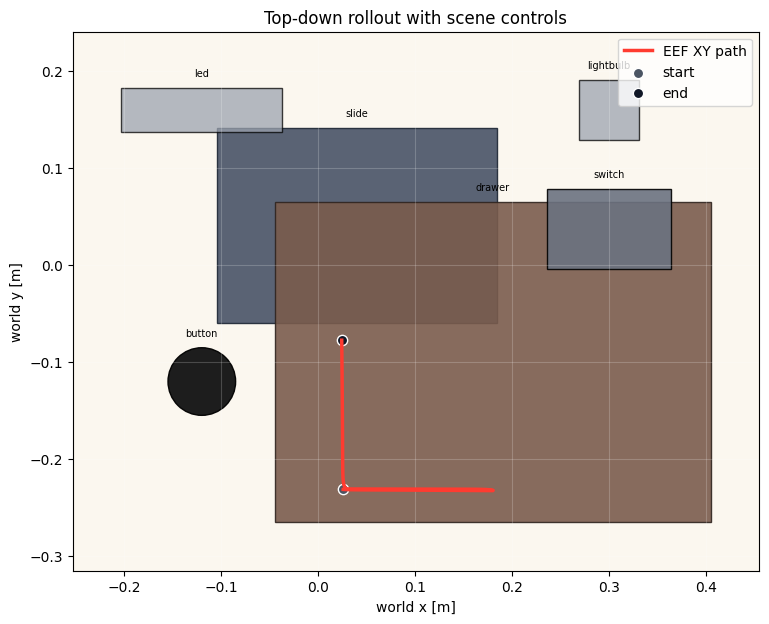

In [79]:
import matplotlib.pyplot as plt

with open(scene_snapshot_path, 'r') as f:
    scene_snapshot = json.load(f)

trace = np.load(trace_path)
eef_xy = trace['eef_xy']

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#fbf7ef')
draw_scene_snapshot(ax, scene_snapshot, eef_xy=eef_xy)
ax.set_xlim(*_scene_limits_from_snapshot(scene_snapshot, eef_xy)[0])
ax.set_ylim(*_scene_limits_from_snapshot(scene_snapshot, eef_xy)[1])
ax.set_title('Top-down rollout with scene controls')
ax.set_xlabel('world x [m]')
ax.set_ylabel('world y [m]')
ax.legend(loc='upper right')

plot_path = out_dir / 'rollout_scene_overlay.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print(f'Saved scene overlay plot: {plot_path}')
print(f'Loaded snapshot: {scene_snapshot_path}')
plt.show()
